Econometrics Project

In [1]:
# Libraries import
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from math import floor, sqrt
from scipy.stats import norm

from arch import arch_model


In [2]:
# Function to download data from Yahoo Finance and Download historical data for Copper and Bloomber Commodity Index
def download_yahoo_data(ticker, start_date, end_date, interval='1d'):
    """
    Download historical data for a ticker from Yahoo Finance.
    
    Parameters:
    - ticker: stock symbol (e.g., 'AAPL' for Apple, 'GOOG' for Google)
    - start_date: start date in 'YYYY-MM-DD' format
    - end_date: end date in 'YYYY-MM-DD' format
    - interval: data frequency ('1d', '1wk', '1mo', '1y', etc.)
    
    Returns:
    - DataFrame with the historical data.
    """
    data = yf.download(ticker, start=start_date, end=end_date, interval=interval)
    return data

start_date_2015 = '2015-01-01'
mid_date_2019 = '2019-12-31'
mid_date_2020 = '2020-01-01'
end_date_2024 = '2024-12-31'
copper_id = 'HG=F'  # Yahoo Finance ticker for Copper Futures 
Bloomberg_Commodity_id = '^BCOM'  # Yahoo Finance ticker for Bloomberg Commodity Index
data_copper = download_yahoo_data(copper_id, start_date_2015, end_date_2024)
data_bloomberg_commodity_idx = download_yahoo_data(Bloomberg_Commodity_id, start_date_2015, end_date_2024)
print(data_copper.head())
print(data_bloomberg_commodity_idx.head())

# Download of data 2015-2019, 2020-2024
# Copper
data_copper_2015_2019 = data_copper.loc[start_date_2015:mid_date_2019]
data_copper_2020_2024 = data_copper.loc[mid_date_2020:end_date_2024]
# Bloomberg Commodity Index
data_bloomberg_2015_2019 = data_bloomberg_commodity_idx.loc[start_date_2015:mid_date_2019]
data_bloomberg_2020_2024 = data_bloomberg_commodity_idx.loc[mid_date_2020:end_date_2024]

/var/folders/mq/vjflf4v17wv_rvtlxmrx4rrc0000gn/T/ipykernel_4996/3776347055.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, interval=interval)
[*********************100%***********************]  1 of 1 completed
/var/folders/mq/vjflf4v17wv_rvtlxmrx4rrc0000gn/T/ipykernel_4996/3776347055.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, interval=interval)
[*********************100%***********************]  1 of 1 completed

Price        Close    High     Low    Open Volume
Ticker        HG=F    HG=F    HG=F    HG=F   HG=F
Date                                             
2015-01-02  2.8385  2.8420  2.8365  2.8420    220
2015-01-05  2.7930  2.8295  2.7880  2.8295    326
2015-01-06  2.8040  2.8060  2.7915  2.7950    312
2015-01-07  2.7960  2.8090  2.7910  2.7920    463
2015-01-08  2.8070  2.8175  2.7865  2.7960    242
Price            Close        High         Low        Open Volume
Ticker           ^BCOM       ^BCOM       ^BCOM       ^BCOM  ^BCOM
Date                                                             
2015-01-02  103.860001  104.680000  103.760002  104.519997      0
2015-01-05  103.870003  104.400002  103.739998  104.209999      0
2015-01-06  104.080002  104.440002  103.389999  104.059998      0
2015-01-07  103.529999  104.400002  103.190002  104.059998      0
2015-01-08  103.639999  103.989998  103.349998  103.690002      0


In [3]:
# Function to convert DataFrame to NumPy array with dates and closing prices
def to_numpy_array(df):
    """
    Convert the DataFrame with 'Date' as index and 'Close' as the column of interest to a NumPy array.
    """
    # Extract dates and closing prices
    dates = df.index.strftime('%Y-%m-%d')  # Convert dates to string format
    closing_prices = df['Close'].values  # Get closing prices as a NumPy array
    
    # Combine the dates and closing prices into a 2D object array
    return np.column_stack((dates, closing_prices))

# Convert both datasets to NumPy arrays
copper_data_array = to_numpy_array(data_copper)
bloomberg_data_array = to_numpy_array(data_bloomberg_commodity_idx)

# Show the resulting arrays
print("Copper Data (NumPy Array):")
print(copper_data_array)
print("Shanghai Composite Data (NumPy Array):")
print(bloomberg_data_array)

# Transform data for 2015-2019 and 2020-2024 into NumPy arrays
copper_2015_2019_array = to_numpy_array(data_copper_2015_2019)
copper_2020_2024_array = to_numpy_array(data_copper_2020_2024)
bloomberg_2015_2019_array = to_numpy_array(data_bloomberg_2015_2019)
bloomberg_2020_2024_array = to_numpy_array(data_bloomberg_2020_2024)

Copper Data (NumPy Array):
[['2015-01-02' 2.8385000228881836]
 ['2015-01-05' 2.7929999828338623]
 ['2015-01-06' 2.803999900817871]
 ...
 ['2024-12-26' 4.072000026702881]
 ['2024-12-27' 4.0625]
 ['2024-12-30' 4.045499801635742]]
Shanghai Composite Data (NumPy Array):
[['2015-01-02' 103.86000061035156]
 ['2015-01-05' 103.87000274658203]
 ['2015-01-06' 104.08000183105469]
 ...
 ['2024-12-26' 98.05000305175781]
 ['2024-12-27' 98.20999908447266]
 ['2024-12-30' 98.87000274658203]]


In [4]:
# Function to compute returns, log returns, and squared log returns
def compute_returns(df):
    # Extract the Close prices and dates using the to_numpy_array function
    data = to_numpy_array(df)
    dates = data[:, 0]  # Dates are in the first column
    close = data[:, 1]  # Closing prices are in the second column

    # Ensure close is a numeric array (in case of any issues)
    close = np.array(close, dtype=float)

    # Calculate simple returns (% change) directly
    returns = close[1:] / close[:-1] - 1

    # Calculate log returns (log difference) without dropping NaNs
    log_returns = np.log(close[:-1] / close[1:])

    # Calculate squared log returns
    log_returns_squared = log_returns ** 2

    # Combine everything into a single numpy array with dates, returns, log returns, squared log returns
    result = np.column_stack((dates[1:], returns, log_returns, log_returns_squared))

    return result

# Compute returns, log returns, and squared log returns for both datasets
copper_metrics = compute_returns(data_copper)
bloomberg_metrics = compute_returns(data_bloomberg_commodity_idx)

# Show the resulting NumPy arrays
print("Copper Metrics (Date, Returns, Log Returns, Squared Log Returns):")
print(copper_metrics[:5])  # Show first 5 rows for Copper

print("Bloomberg Commodity Metrics (Date, Returns, Log Returns, Squared Log Returns):")
print(bloomberg_metrics[:5])  # Show first 5 rows for Bloomberg Commodity

# Compute metrics for 2015-2019 and 2020-2024 datasets
copper_2015_2019_metrics = compute_returns(data_copper_2015_2019)
copper_2020_2024_metrics = compute_returns(data_copper_2020_2024)
bloomberg_2015_2019_metrics = compute_returns(data_bloomberg_2015_2019)
bloomberg_2020_2024_metrics = compute_returns(data_bloomberg_2020_2024)


Copper Metrics (Date, Returns, Log Returns, Squared Log Returns):
[['2015-01-05' -0.016029607076777364 0.016159470875211406
  0.00026112849896680566]
 ['2015-01-06' 0.003938388131620396 -0.003930652983774201
  1.5450032878853028e-05]
 ['2015-01-07' -0.0028530304158856934 0.0028571080647803926
  8.16306649383316e-06]
 ['2015-01-08' 0.003934162363734339 -0.003926443784455239
  1.5416960792487182e-05]
 ['2015-01-09' -0.005878160543278388 0.005895504931094553
  3.475697839256019e-05]]
Bloomberg Commodity Metrics (Date, Returns, Log Returns, Squared Log Returns):
[['2015-01-05' 9.630402630156354e-05 -9.629938936656894e-05
  9.273572392374052e-09]
 ['2015-01-06' 0.002021749099063719 -0.002019708114796475
  4.079220868974731e-06]
 ['2015-01-07' -0.005284425846288854 0.005298437809805732
  2.807344322437896e-05]
 ['2015-01-08' 0.001062499871038014 -0.0010619358175524988
  1.127707680600894e-06]
 ['2015-01-09' -0.00019294329587193904 0.00019296191182423942
  3.723429941486555e-08]]


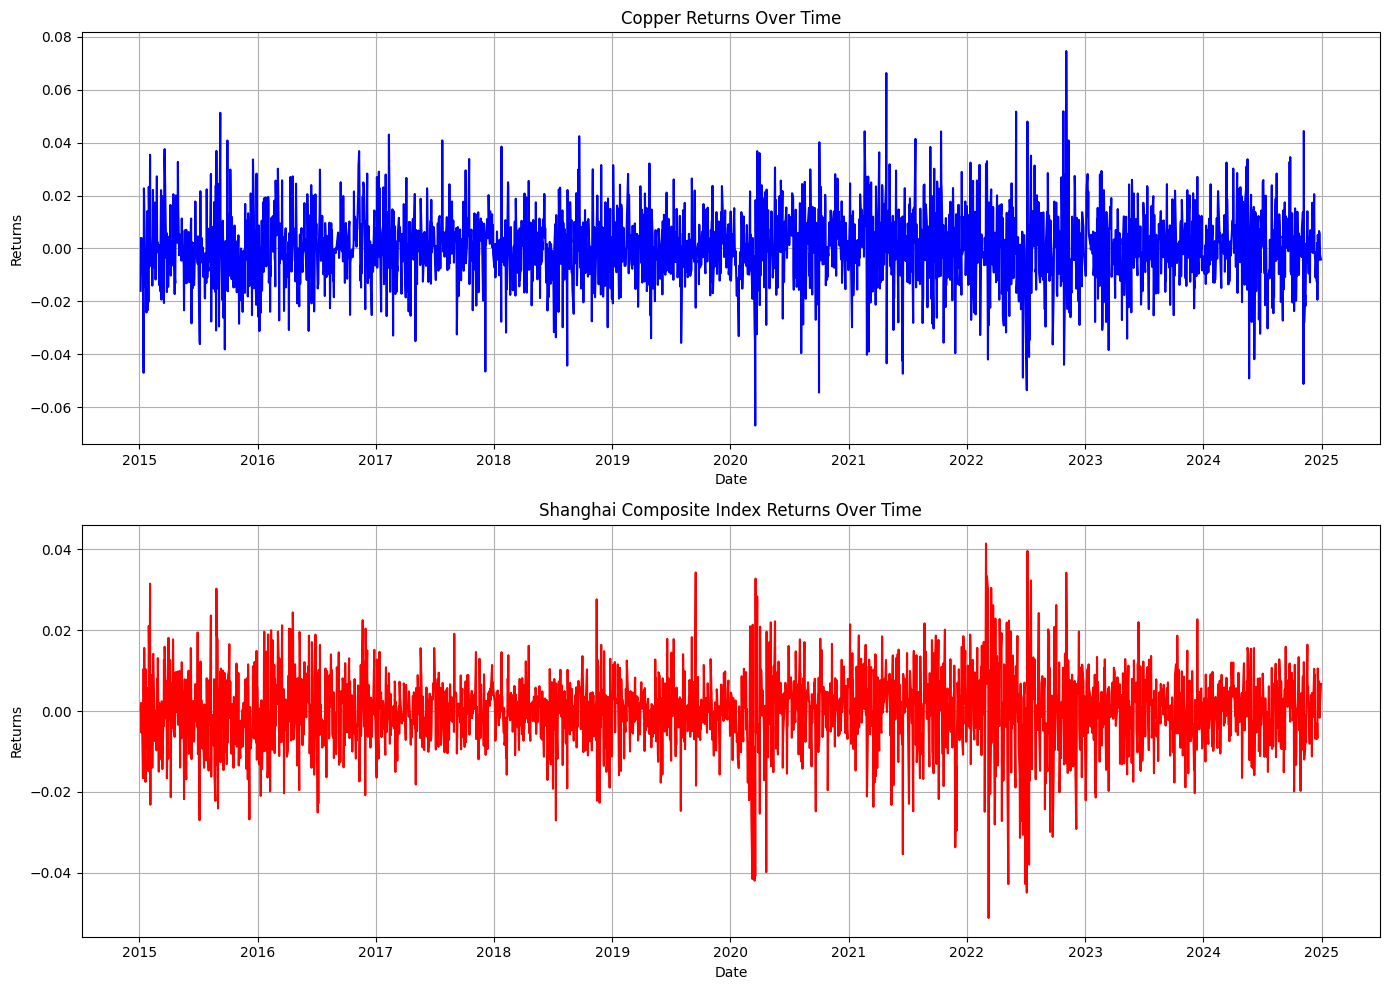

In [5]:
# Convert to datetime if not already
copper_dates = pd.to_datetime(copper_metrics[:, 0])
bloomberg_dates = pd.to_datetime(bloomberg_metrics[:, 0])

plt.figure(figsize=(14, 10))

# Copper Returns
plt.subplot(2, 1, 1)
plt.plot(copper_dates, copper_metrics[:, 1], color='blue')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.title('Copper Returns Over Time')
plt.grid(True)

# Bloomberg Returns
plt.subplot(2, 1, 2)
plt.plot(bloomberg_dates, bloomberg_metrics[:, 1], color='red')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.title('Shanghai Composite Index Returns Over Time')
plt.grid(True)

plt.tight_layout()
plt.show()


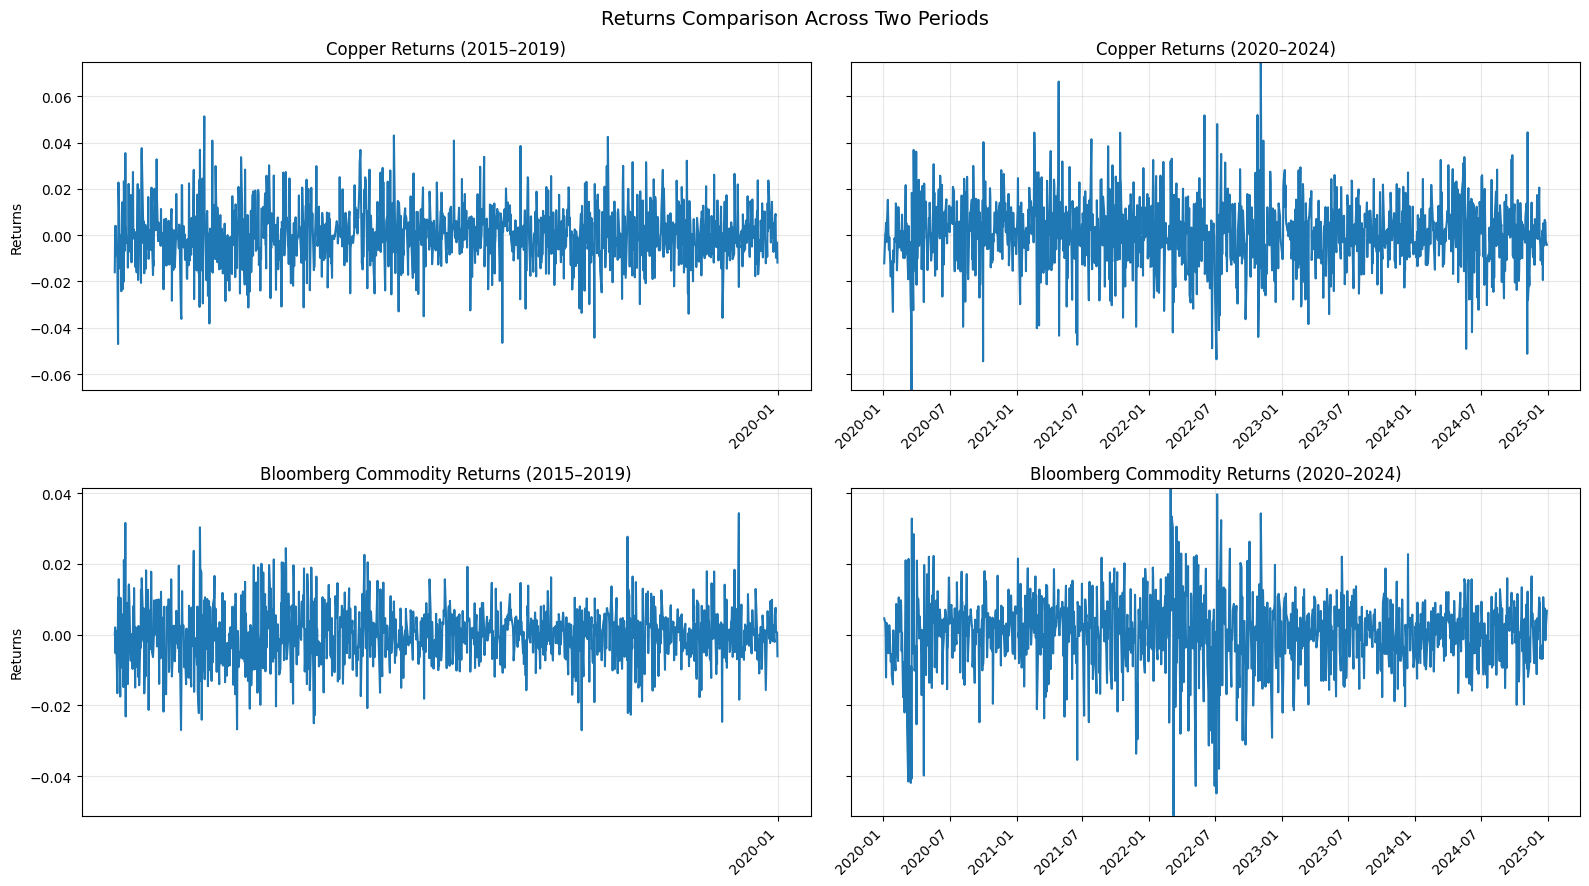

In [6]:
import numpy as np
import pandas as pd

def _to_datetime(col):
    """
    Convert a 1D array/Series of dates into pandas datetime64[ns],
    handling ISO strings, Unix (s/ms), YYYYMMDD ints, and Excel serials.
    """
    s = pd.Series(col)

    # Already datetime-like
    if np.issubdtype(s.dtype, np.datetime64):
        return pd.to_datetime(s)

    # Object or string → try generic parse
    if s.dtype == object or s.dtype == "string":
        parsed = pd.to_datetime(s, errors="coerce", utc=False)
        if parsed.notna().mean() > 0.95:
            return parsed

    # Numeric formats
    if np.issubdtype(s.dtype, np.number):
        vals = s.astype("float64")
        abs_vals = np.abs(vals.dropna())

        is_unix_s  = abs_vals.between(1e8, 1e10).mean() > 0.8
        is_unix_ms = abs_vals.between(1e11, 2e12).mean() > 0.8
        is_yyyymmdd = abs_vals.between(2e7, 3e8).mean() > 0.8
        is_excel = abs_vals.between(20000, 60000).mean() > 0.8

        if is_unix_ms:
            return pd.to_datetime(s, unit="ms", errors="coerce")
        if is_unix_s:
            return pd.to_datetime(s, unit="s", errors="coerce")
        if is_yyyymmdd:
            return pd.to_datetime(s.astype("Int64").astype(str), format="%Y%m%d", errors="coerce")
        if is_excel:
            return pd.to_datetime(s, origin="1899-12-30", unit="D", errors="coerce")

        parsed = pd.to_datetime(s, errors="coerce")
        if parsed.notna().any():
            return parsed

    return pd.to_datetime(s, errors="coerce")


# Convert date columns to datetime
cu15_dates = _to_datetime(copper_2015_2019_metrics[:, 0])
cu24_dates = _to_datetime(copper_2020_2024_metrics[:, 0])
bl15_dates = _to_datetime(bloomberg_2015_2019_metrics[:, 0])
bl24_dates = _to_datetime(bloomberg_2020_2024_metrics[:, 0])

# Extract returns
cu15_ret = copper_2015_2019_metrics[:, 1].astype(float)
cu24_ret = copper_2020_2024_metrics[:, 1].astype(float)
bl15_ret = bloomberg_2015_2019_metrics[:, 1].astype(float)
bl24_ret = bloomberg_2020_2024_metrics[:, 1].astype(float)

# Set y-limits per asset for fair comparison across its two periods
cu_min, cu_max = np.nanmin([cu15_ret.min(), cu24_ret.min()]), np.nanmax([cu15_ret.max(), cu24_ret.max()])
bl_min, bl_max = np.nanmin([bl15_ret.min(), bl24_ret.min()]), np.nanmax([bl15_ret.max(), bl24_ret.max()])

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey='row')
(ax_cu_15, ax_cu_24), (ax_bl_15, ax_bl_24) = axes

# Date formatter (monthly ticks, YYYY-MM)
fmt = mdates.DateFormatter('%Y-%m')
locator = mdates.AutoDateLocator(minticks=6, maxticks=12)

# --- Copper 2015-2019 ---
ax_cu_15.plot(cu15_dates, cu15_ret)
ax_cu_15.set_title('Copper Returns (2015–2019)')
ax_cu_15.set_ylabel('Returns')
ax_cu_15.grid(True, alpha=0.3)
ax_cu_15.xaxis.set_major_locator(locator)
ax_cu_15.xaxis.set_major_formatter(fmt)
ax_cu_15.set_ylim(cu_min, cu_max)

# --- Copper 2020-2024 ---
ax_cu_24.plot(cu24_dates, cu24_ret)
ax_cu_24.set_title('Copper Returns (2020–2024)')
ax_cu_24.grid(True, alpha=0.3)
ax_cu_24.xaxis.set_major_locator(locator)
ax_cu_24.xaxis.set_major_formatter(fmt)
ax_cu_24.set_ylim(cu_min, cu_max)

# --- Bloomberg Commodity Index 2015-2019 ---
ax_bl_15.plot(bl15_dates, bl15_ret)
ax_bl_15.set_title('Bloomberg Commodity Returns (2015–2019)')
ax_bl_15.set_ylabel('Returns')
ax_bl_15.grid(True, alpha=0.3)
ax_bl_15.xaxis.set_major_locator(locator)
ax_bl_15.xaxis.set_major_formatter(fmt)
ax_bl_15.set_ylim(bl_min, bl_max)

# --- Bloomberg Commodity Index 2020-2024 ---
ax_bl_24.plot(bl24_dates, bl24_ret)
ax_bl_24.set_title('Bloomberg Commodity Returns (2020–2024)')
ax_bl_24.grid(True, alpha=0.3)
ax_bl_24.xaxis.set_major_locator(locator)
ax_bl_24.xaxis.set_major_formatter(fmt)
ax_bl_24.set_ylim(bl_min, bl_max)

for ax in axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

fig.suptitle('Returns Comparison Across Two Periods', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


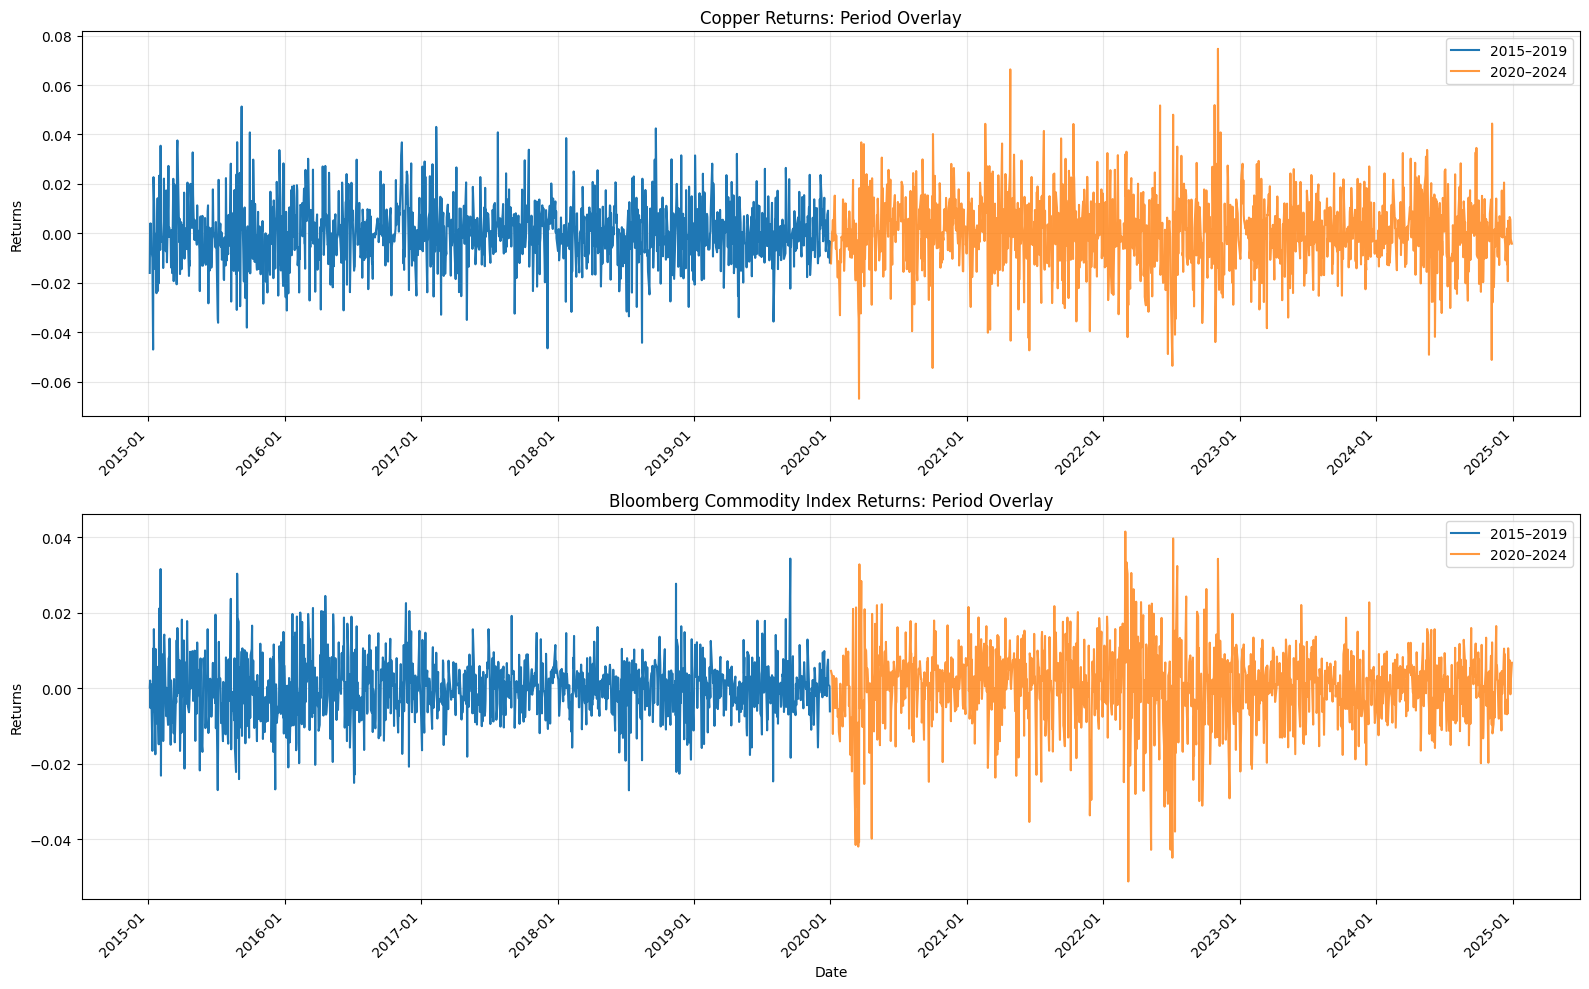

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

# Copper overlay
ax1.plot(cu15_dates, cu15_ret, label='2015–2019')
ax1.plot(cu24_dates, cu24_ret, label='2020–2024', alpha=0.8)
ax1.set_title('Copper Returns: Period Overlay')
ax1.set_ylabel('Returns')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.xaxis.set_major_locator(locator)
ax1.xaxis.set_major_formatter(fmt)

# Shanghai overlay
ax2.plot(bl15_dates, bl15_ret, label='2015–2019')
ax2.plot(bl24_dates, bl24_ret, label='2020–2024', alpha=0.8)
ax2.set_title('Bloomberg Commodity Index Returns: Period Overlay')
ax2.set_xlabel('Date')
ax2.set_ylabel('Returns')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.xaxis.set_major_locator(locator)
ax2.xaxis.set_major_formatter(fmt)

for ax in (ax1, ax2):
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

plt.tight_layout()
plt.show()


In [8]:
# Function to compute volatility (standard deviation of squared log returns)
def compute_volatility(metrics):
    squared_log_returns = metrics[:, 3]  # Extract squared log returns
    volatility = np.std(squared_log_returns)  # Compute the standard deviation of squared log returns
    return volatility

# Calculate volatilities for each period and dataset
copper_volatility_2015_2019 = compute_volatility(copper_2015_2019_metrics)
copper_volatility_2020_2024 = compute_volatility(copper_2020_2024_metrics)
shanghai_volatility_2015_2019 = compute_volatility(bloomberg_2015_2019_metrics)
shanghai_volatility_2020_2024 = compute_volatility(bloomberg_2020_2024_metrics)

# Print volatilities for each dataset and period
print("Copper Volatility 2015-2019:", copper_volatility_2015_2019)
print("Copper Volatility 2020-2024:", copper_volatility_2020_2024)
print("Shanghai Composite Volatility 2015-2019:", shanghai_volatility_2015_2019)
print("Shanghai Composite Volatility 2020-2024:", shanghai_volatility_2020_2024)


Copper Volatility 2015-2019: 0.00027907053117921956
Copper Volatility 2020-2024: 0.0004285201009693376
Shanghai Composite Volatility 2015-2019: 0.00011204947452871292
Shanghai Composite Volatility 2020-2024: 0.00022940538424397091


In [9]:
# =========================
# HAC tests for volatility + ASSUMPTION CHECKS
# =========================

import numpy as np
import pandas as pd
import warnings
from math import floor
from scipy.stats import norm, kurtosis, jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model

# ---------- 1) Utilities ----------

def compute_metrics_df(df):
    """
    Return a tidy DataFrame with Date, Return, LogReturn, SqLogReturn.
    NOTE: Fixes log-return direction to log(S_t / S_{t-1}).
    """
    out = pd.DataFrame(index=df.index.copy())
    close = df["Close"].astype(float)
    out["Return"] = close.pct_change()
    out["LogReturn"] = np.log(close / close.shift(1))
    out["SqLogReturn"] = out["LogReturn"]**2
    out = out.dropna()
    out = out.reset_index().rename(columns={"index": "Date"})
    return out[["Date", "Return", "LogReturn", "SqLogReturn"]]


def split_periods(df_metrics, start1="2015-01-01", end1="2019-12-31",
                  start2="2020-01-01", end2="2024-12-31"):
    """Split a metrics DataFrame into two periods (pre & post)."""
    m = df_metrics.copy()
    m["Date"] = pd.to_datetime(m["Date"])
    pre  = m[(m["Date"] >= pd.to_datetime(start1)) & (m["Date"] <= pd.to_datetime(end1))].copy()
    post = m[(m["Date"] >= pd.to_datetime(start2)) & (m["Date"] <= pd.to_datetime(end2))].copy()
    return pre.reset_index(drop=True), post.reset_index(drop=True)


def _autobandwidth_newey_west(n):
    """
    Automatic lag/truncation parameter q (Newey–West) for mean inference.
    Use a common rule-of-thumb: q = floor(4 * (n/100)^(2/9)) ∨ 1
    """
    q = int(np.floor(4.0 * (n / 100.0) ** (2.0 / 9.0)))
    return max(q, 1)


def long_run_variance_newey_west(x, q=None):
    """
    Newey–West long-run variance estimator for a (mean-zero) series x.
    Returns LRV = gamma(0) + 2 * sum_{h=1}^q w_h * gamma(h), with Bartlett weights.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.shape[0]
    if n < 3: return np.nan
    if q is None: q = _autobandwidth_newey_west(n)

    x_centered = x - x.mean()
    gamma0 = np.dot(x_centered, x_centered) / n
    lrv = gamma0
    for h in range(1, q + 1):
        cov_h = np.dot(x_centered[h:], x_centered[:-h]) / n
        weight = 1.0 - h / (q + 1.0)  # Bartlett kernel
        lrv += 2.0 * weight * cov_h
    return lrv


def hac_two_sample_mean_test(x, y, qx=None, qy=None, alternative="two-sided"):
    """
    HAC-robust two-sample test for equality of means of correlated series.
    x, y: arrays of observations (here, squared log-returns).
    """
    x = np.asarray(x, dtype=float); x = x[~np.isnan(x)]
    y = np.asarray(y, dtype=float); y = y[~np.isnan(y)]
    n1, n2 = len(x), len(y)
    if n1 < 3 or n2 < 3:
        return {"stat": np.nan, "pvalue": np.nan, "se": np.nan, "n1": n1, "n2": n2}

    if qx is None: qx = _autobandwidth_newey_west(n1)
    if qy is None: qy = _autobandwidth_newey_west(n2)

    lrv_x = long_run_variance_newey_west(x, q=qx)
    lrv_y = long_run_variance_newey_west(y, q=qy)

    se = np.sqrt(lrv_x / n1 + lrv_y / n2)
    diff = x.mean() - y.mean()
    z = diff / se if se > 0 else np.nan

    if alternative == "two-sided":
        pval = 2.0 * (1.0 - norm.cdf(abs(z)))
    elif alternative == "larger":
        pval = 1.0 - norm.cdf(z)
    else:
        pval = norm.cdf(z)

    return {
        "mean_x": x.mean(), "mean_y": y.mean(),
        "diff": diff, "se": se, "stat": z, "pvalue": pval,
        "lags_x": qx, "lags_y": qy, "n1": n1, "n2": n2
    }


def pretty_test(name, res):
    return {
        "Test": name, "n1": res["n1"], "n2": res["n2"],
        "mean_x": res["mean_x"], "mean_y": res["mean_y"],
        "diff": res["diff"], "HAC_SE": res["se"],
        "z_stat": res["stat"], "p_value": res["pvalue"],
        "lags_x": res["lags_x"], "lags_y": res["lags_y"]
    }

# ---------- 1.b) Assumption-check helpers ----------

def adf_test(x):
    # H0: unit root (non-stationary). We want to REJECT H0.
    res = adfuller(x, autolag='AIC')
    stat, pval = res[0], res[1]
    return stat, pval

def kpss_test(x, regression='c'):
    # H0: stationary (level or trend depending on regression). We want to NOT reject H0.
    # If series is short, KPSS can be over-sensitive; catch warnings.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, pval, lags, crit = kpss(x, regression=regression, nlags="auto")
    return stat, pval

def lb_test(x, lags=(5,10,20)):
    # Ljung-Box on squared returns: checks for remaining dependence (we expect some, but not explosive).
    pvals = {}
    for L in lags:
        lb = acorr_ljungbox(x, lags=[L], return_df=True)
        pvals[L] = float(lb["lb_pvalue"].iloc[0])
    return pvals

def rolling_cv(x, window=126):
    # Coefficient of variation of rolling variance as a rough stability check (lower is more stable).
    s = pd.Series(x).dropna()
    if len(s) < window*2:
        return np.nan
    rv = s.rolling(window).var()
    return float(rv.std() / rv.mean())

def garch_moment_checks(r):
    """
    Fit GARCH(1,1) to returns and check:
      - alpha + beta < 1   (covariance-stationary/ergodic volatility)
      - 3*alpha^2 + 2*alpha*beta + beta^2 < 1  (finite 4th moment)
    """
    r = pd.Series(r).dropna().values
    if len(r) < 200:  # need some data
        return np.nan, np.nan, np.nan, np.nan, False, False
    am = arch_model(100*r, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
    res = am.fit(disp="off")
    pars = res.params
    alpha = pars.get("alpha[1]", np.nan)
    beta  = pars.get("beta[1]", np.nan)
    omega = pars.get("omega", np.nan)
    cov_stat = (alpha + beta) < 1 if np.isfinite(alpha) and np.isfinite(beta) else False
    finite_m4 = (3*alpha**2 + 2*alpha*beta + beta**2) < 1 if np.isfinite(alpha) and np.isfinite(beta) else False
    return alpha, beta, omega, res.loglikelihood, cov_stat, finite_m4

def check_assumptions(name, ret_series, sq_series):
    """
    Run all diagnostics required by slides:
      - Weak stationarity of r_t^2: ADF reject unit root; KPSS do not reject stationarity
      - Dependence is present but stable: Ljung-Box p-values often < 0.01 at some lags
      - Long-run variance finite (NW LRV finite positive)
      - Optional: GARCH alpha+beta<1 and finite 4th moment
    """
    x = pd.Series(sq_series).dropna().values
    n = len(x)
    out = {"series": name, "n": n}

    # ADF & KPSS on squared returns
    adf_stat, adf_p = adf_test(x)
    kpss_stat, kpss_p = kpss_test(x, regression='c')

    out.update({
        "ADF_stat": adf_stat, "ADF_p": adf_p,
        "KPSS_stat": kpss_stat, "KPSS_p": kpss_p
    })

    # Ljung-Box on squared returns (lags 5,10,20)
    lb_p = lb_test(x, lags=(5,10,20))
    out.update({f"LB_p_lag{L}": p for L, p in lb_p.items()})

    # LRV finiteness (should be finite positive)
    lrv = long_run_variance_newey_west(x)
    out["LRV_NW"] = lrv

    # Rolling variance stability (CV)
    out["RollVar_CV_126"] = rolling_cv(x, window=126)

    # Optional: GARCH(1,1) checks on raw returns (ergodicity proxy)
    r = pd.Series(ret_series).dropna().values
    a, b, w, ll, cov_stat, finite_m4 = garch_moment_checks(r)
    out.update({
        "GARCH_alpha": a, "GARCH_beta": b, "GARCH_alpha+beta": (a+b if np.isfinite(a) and np.isfinite(b) else np.nan),
        "GARCH_cov_stationary": cov_stat, "GARCH_finite_M4": finite_m4
    })

    return out

# ---------- 2) Build metrics from your existing data ----------

# Reuse your already-downloaded dataframes:
# - data_copper
# - data_bloomberg_commodity_idx

cu_metrics = compute_metrics_df(data_copper)
bl_metrics = compute_metrics_df(data_bloomberg_commodity_idx)

cu_pre, cu_post = split_periods(cu_metrics)
bl_pre, bl_post = split_periods(bl_metrics)

# Series to test: squared log-returns (volatility proxy)
cu_pre_sq  = cu_pre["SqLogReturn"].values
cu_post_sq = cu_post["SqLogReturn"].values
bl_pre_sq  = bl_pre["SqLogReturn"].values
bl_post_sq = bl_post["SqLogReturn"].values

# ---------- 2.b) Assumption checks ----------
diag_rows = []
diag_rows.append(check_assumptions("Copper 2015–2019", ret_series=cu_pre["LogReturn"].values, sq_series=cu_pre_sq))
diag_rows.append(check_assumptions("Copper 2020–2024", ret_series=cu_post["LogReturn"].values, sq_series=cu_post_sq))
diag_rows.append(check_assumptions("BCOM 2015–2019",   ret_series=bl_pre["LogReturn"].values, sq_series=bl_pre_sq))
diag_rows.append(check_assumptions("BCOM 2020–2024",   ret_series=bl_post["LogReturn"].values, sq_series=bl_post_sq))

assumption_df = pd.DataFrame(diag_rows)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
print("\n=== Assumption checks for HAC test (squared log-returns) ===")
print(assumption_df[
    ["series","n","ADF_stat","ADF_p","KPSS_stat","KPSS_p",
     "LB_p_lag5","LB_p_lag10","LB_p_lag20","LRV_NW","RollVar_CV_126",
     "GARCH_alpha","GARCH_beta","GARCH_alpha+beta","GARCH_cov_stationary","GARCH_finite_M4"]
])

# ---------- 3) Time-effect tests (2015–2019 vs 2020–2024) ----------
res_cu_time = hac_two_sample_mean_test(cu_post_sq, cu_pre_sq)  # post - pre
res_bl_time = hac_two_sample_mean_test(bl_post_sq, bl_pre_sq)  # post - pre

# ---------- 4) Cross-asset tests within each period ----------
res_cross_pre  = hac_two_sample_mean_test(cu_pre_sq,  bl_pre_sq)   # copper - bcom (2015–2019)
res_cross_post = hac_two_sample_mean_test(cu_post_sq, bl_post_sq)  # copper - bcom (2020–2024)

# ---------- 5) Display results ----------
summary_rows = []
summary_rows.append(pretty_test("TIME Copper: mean(post) - mean(pre)", res_cu_time))
summary_rows.append(pretty_test("TIME BCOM: mean(post) - mean(pre)",   res_bl_time))
summary_rows.append(pretty_test("CROSS Pre (2015–2019): mean(Cu) - mean(BCOM)", res_cross_pre))
summary_rows.append(pretty_test("CROSS Post (2020–2024): mean(Cu) - mean(BCOM)", res_cross_post))
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df[["Test","n1","n2","mean_x","mean_y","diff","HAC_SE","z_stat","p_value","lags_x","lags_y"]]
print("\n=== HAC/Newey–West robust tests on mean volatility (squared log-returns) ===")
print(summary_df)

# ---------- 6) (Optional) GARCH-based version ----------
def garch_conditional_variance_series(df_metrics):
    """
    Fit a GARCH(1,1) with zero mean and return the conditional variance series aligned to df_metrics.
    """
    r = df_metrics["LogReturn"].values
    am = arch_model(r * 100, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")  # scale in %
    res = am.fit(disp="off")
    sigma_pct = np.asarray(res.conditional_volatility)
    sigma = sigma_pct / 100.0
    cond_var = sigma**2
    return pd.Series(cond_var, index=df_metrics.index)

cu_metrics_g = cu_metrics.copy()
bl_metrics_g = bl_metrics.copy()
cu_metrics_g["CondVar"] = garch_conditional_variance_series(cu_metrics_g)
bl_metrics_g["CondVar"] = garch_conditional_variance_series(bl_metrics_g)

cu_pre_g, cu_post_g = split_periods(cu_metrics_g)
bl_pre_g, bl_post_g = split_periods(bl_metrics_g)

res_cu_time_g = hac_two_sample_mean_test(cu_post_g["CondVar"].values, cu_pre_g["CondVar"].values)
res_bl_time_g = hac_two_sample_mean_test(bl_post_g["CondVar"].values, bl_pre_g["CondVar"].values)
res_cross_pre_g  = hac_two_sample_mean_test(cu_pre_g["CondVar"].values,  bl_pre_g["CondVar"].values)
res_cross_post_g = hac_two_sample_mean_test(cu_post_g["CondVar"].values, bl_post_g["CondVar"].values)

summary_rows_g = []
summary_rows_g.append(pretty_test("TIME Copper (GARCH var): post - pre", res_cu_time_g))
summary_rows_g.append(pretty_test("TIME BCOM (GARCH var): post - pre",   res_bl_time_g))
summary_rows_g.append(pretty_test("CROSS Pre (GARCH var): Cu - BCOM",    res_cross_pre_g))
summary_rows_g.append(pretty_test("CROSS Post (GARCH var): Cu - BCOM",   res_cross_post_g))
summary_df_g = pd.DataFrame(summary_rows_g)[summary_df.columns]
print("\n=== HAC/Newey–West robust tests on mean GARCH conditional variance ===")
print(summary_df_g)



=== Assumption checks for HAC test (squared log-returns) ===
             series     n  ADF_stat       ADF_p  KPSS_stat   KPSS_p  \
0  Copper 2015–2019  1254  -32.4478           0    1.21479     0.01   
1  Copper 2020–2024  1258  -10.6351 5.09687e-19   0.312085      0.1   
2    BCOM 2015–2019  1257  -10.8512 1.52682e-19    2.08254     0.01   
3    BCOM 2020–2024  1257  -7.71135  1.2614e-11   0.660262 0.017158   

    LB_p_lag5  LB_p_lag10  LB_p_lag20      LRV_NW  RollVar_CV_126  \
0   0.0360114  0.00170912   0.0071235 8.82584e-08        0.427354   
1 7.95057e-11 1.27752e-11 6.41571e-09 2.96539e-07        0.654068   
2 3.76061e-15 1.33424e-17 2.23962e-19 2.20852e-08        0.609858   
3 3.86926e-51 1.20264e-78 3.30028e-90 1.21899e-07         1.29484   

   GARCH_alpha  GARCH_beta  GARCH_alpha+beta  GARCH_cov_stationary  \
0    0.0128744     0.96822          0.981094                  True   
1     0.110715    0.749823          0.860538                  True   
2    0.0410848    0.943454

In [10]:
# =========================
# HAC tests for volatility + ASSUMPTION CHECKS (clean version)
# =========================

import numpy as np
import pandas as pd
import warnings
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

# ---------- 1) Utilities ----------

def compute_metrics_df(df):
    """
    Return a tidy DataFrame with Date, Return, LogReturn, SqLogReturn.
    NOTE: log-return = log(S_t / S_{t-1})
    """
    out = pd.DataFrame(index=df.index.copy())
    close = df["Close"].astype(float)
    out["Return"] = close.pct_change()
    out["LogReturn"] = np.log(close / close.shift(1))
    out["SqLogReturn"] = out["LogReturn"]**2
    out = out.dropna()
    out = out.reset_index().rename(columns={"index": "Date"})
    return out[["Date", "Return", "LogReturn", "SqLogReturn"]]


def split_periods(df_metrics, start1="2015-01-01", end1="2019-12-31",
                  start2="2020-01-01", end2="2024-12-31"):
    """Split a metrics DataFrame into two periods (pre & post)."""
    m = df_metrics.copy()
    m["Date"] = pd.to_datetime(m["Date"])
    pre  = m[(m["Date"] >= pd.to_datetime(start1)) & (m["Date"] <= pd.to_datetime(end1))].copy()
    post = m[(m["Date"] >= pd.to_datetime(start2)) & (m["Date"] <= pd.to_datetime(end2))].copy()
    return pre.reset_index(drop=True), post.reset_index(drop=True)


def _autobandwidth_newey_west(n):
    """
    Automatic lag/truncation parameter q (Newey–West).
    q = floor(4 * (n/100)^(2/9))  (min 1)
    """
    q = int(np.floor(4.0 * (n / 100.0) ** (2.0 / 9.0)))
    return max(q, 1)


def long_run_variance_newey_west(x, q=None):
    """
    Newey–West long-run variance estimator for a (mean-zero) series x.
    LRV = gamma(0) + 2 * sum_{h=1}^q w_h * gamma(h), Bartlett weights.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.shape[0]
    if n < 3:
        return np.nan
    if q is None:
        q = _autobandwidth_newey_west(n)

    x_centered = x - x.mean()
    gamma0 = np.dot(x_centered, x_centered) / n
    lrv = gamma0
    for h in range(1, q + 1):
        cov_h = np.dot(x_centered[h:], x_centered[:-h]) / n
        weight = 1.0 - h / (q + 1.0)  # Bartlett kernel
        lrv += 2.0 * weight * cov_h
    return lrv


def hac_two_sample_mean_test(x, y, qx=None, qy=None, alternative="two-sided"):
    """
    HAC-robust two-sample test for equality of means of correlated series.
    x, y: arrays of observations (here, squared log-returns).
    """
    x = np.asarray(x, dtype=float); x = x[~np.isnan(x)]
    y = np.asarray(y, dtype=float); y = y[~np.isnan(y)]
    n1, n2 = len(x), len(y)
    if n1 < 3 or n2 < 3:
        return {"stat": np.nan, "pvalue": np.nan, "se": np.nan, "n1": n1, "n2": n2}

    if qx is None: qx = _autobandwidth_newey_west(n1)
    if qy is None: qy = _autobandwidth_newey_west(n2)

    lrv_x = long_run_variance_newey_west(x, q=qx)
    lrv_y = long_run_variance_newey_west(y, q=qy)

    se = np.sqrt(lrv_x / n1 + lrv_y / n2)
    diff = x.mean() - y.mean()
    z = diff / se if se > 0 else np.nan

    if alternative == "two-sided":
        pval = 2.0 * (1.0 - norm.cdf(abs(z)))
    elif alternative == "larger":
        pval = 1.0 - norm.cdf(z)
    else:
        pval = norm.cdf(z)

    return {
        "mean_x": x.mean(), "mean_y": y.mean(),
        "diff": diff, "se": se, "stat": z, "pvalue": pval,
        "lags_x": qx, "lags_y": qy, "n1": n1, "n2": n2
    }


def pretty_test(name, res):
    return {
        "Test": name, "n1": res["n1"], "n2": res["n2"],
        "mean_x": res["mean_x"], "mean_y": res["mean_y"],
        "diff": res["diff"], "HAC_SE": res["se"],
        "z_stat": res["stat"], "p_value": res["pvalue"],
        "lags_x": res["lags_x"], "lags_y": res["lags_y"]
    }

# ---------- 1.b) Assumption-check helpers ----------

def adf_test(x):
    # H0: unit root (non-stationary). We want to REJECT H0.
    res = adfuller(x, autolag='AIC')
    return res[0], res[1]

def kpss_test(x, regression='c'):
    # H0: stationary (level if 'c', trend if 'ct'). We want to NOT reject H0.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, pval, lags, crit = kpss(x, regression=regression, nlags="auto")
    return stat, pval

def lb_test(x, lags=(5,10,20)):
    # Ljung-Box on squared returns (informational).
    pvals = {}
    for L in lags:
        lb = acorr_ljungbox(x, lags=[L], return_df=True)
        pvals[L] = float(lb["lb_pvalue"].iloc[0])
    return pvals

def rolling_cv(x, window=126):
    # Coefficient of variation of rolling variance (lower = more stable).
    s = pd.Series(x).dropna()
    if len(s) < window*2:
        return np.nan
    rv = s.rolling(window).var()
    return float(rv.std() / rv.mean())

def mean_zero_and_variance_checks(r, eps=1e-14):
    """
    Checks on log returns:
      - mean-zero test (two-sided z-test)
      - zero-variance flags for returns and squared returns
    """
    r = pd.Series(r).dropna().values
    n = len(r)
    if n < 3:
        return np.nan, np.nan, np.nan, np.nan, True, True

    mean_r = np.mean(r)
    var_r = np.var(r, ddof=1)
    se_mean = np.sqrt(var_r / n) if var_r > 0 else np.nan
    z_mean = mean_r / se_mean if (se_mean is not np.nan and se_mean > 0) else np.nan
    p_mean = 2 * (1 - norm.cdf(abs(z_mean))) if np.isfinite(z_mean) else np.nan

    zero_var_returns = bool(var_r <= eps)

    # For squared returns:
    sq = r**2
    var_sq = np.var(sq, ddof=1)
    zero_var_sq = bool(var_sq <= eps)

    return mean_r, var_r, z_mean, p_mean, zero_var_returns, zero_var_sq

def check_assumptions(name, ret_series, sq_series):
    """
    Diagnostics required by the slides:
      - Mean of log returns ≈ 0 (report z-test and p-value)
      - Weak stationarity of r_t^2: ADF reject unit root; KPSS do not reject stationarity
      - Serial dependence info: Ljung–Box p-values on r_t^2
      - Long-run variance finite (NW LRV finite positive)
      - Rolling variance CV (stability indicator)
      - Zero-variance flags to prevent invalid tests
    """
    # Squared returns array
    x = pd.Series(sq_series).dropna().values
    n = len(x)

    out = {"series": name, "n": n}

    # --- Mean-zero & zero-variance checks on log returns ---
    r = pd.Series(ret_series).dropna().values
    mean_r, var_r, z_mean, p_mean, zero_var_r, zero_var_sq = mean_zero_and_variance_checks(r)
    out.update({
        "Mean_LogRet": mean_r,
        "Var_LogRet": var_r,
        "z_mean0": z_mean,
        "p_mean0": p_mean,
        "ZeroVar_Returns": zero_var_r,
        "ZeroVar_SqReturns": zero_var_sq
    })

    # --- ADF & KPSS on squared returns ---
    if n >= 10 and not zero_var_sq:
        adf_stat, adf_p = adf_test(x)
        kpss_stat, kpss_p = kpss_test(x, regression='c')
    else:
        adf_stat = adf_p = kpss_stat = kpss_p = np.nan

    out.update({
        "ADF_stat": adf_stat, "ADF_p": adf_p,
        "KPSS_stat": kpss_stat, "KPSS_p": kpss_p
    })

    # --- Ljung–Box on squared returns (informational) ---
    if n >= 20 and not zero_var_sq:
        lb_p = lb_test(x, lags=(5,10,20))
        out.update({f"LB_p_lag{L}": p for L, p in lb_p.items()})
    else:
        out.update({"LB_p_lag5": np.nan, "LB_p_lag10": np.nan, "LB_p_lag20": np.nan})

    # --- LRV finiteness (should be finite positive) ---
    out["LRV_NW"] = float(long_run_variance_newey_west(x)) if (n >= 10 and not zero_var_sq) else np.nan

    # --- Rolling variance stability (CV) ---
    out["RollVar_CV_126"] = rolling_cv(x, window=126) if n >= 252 else np.nan

    return out

# ---------- 2) Build metrics from your existing data ----------

# Reuse your already-downloaded dataframes:
# - data_copper
# - data_bloomberg_commodity_idx

cu_metrics = compute_metrics_df(data_copper)
bl_metrics = compute_metrics_df(data_bloomberg_commodity_idx)

cu_pre, cu_post = split_periods(cu_metrics)
bl_pre, bl_post = split_periods(bl_metrics)

# Series to test: squared log-returns (volatility proxy)
cu_pre_sq  = cu_pre["SqLogReturn"].values
cu_post_sq = cu_post["SqLogReturn"].values
bl_pre_sq  = bl_pre["SqLogReturn"].values
bl_post_sq = bl_post["SqLogReturn"].values

# ---------- 2.b) Assumption checks ----------
diag_rows = []
diag_rows.append(check_assumptions("Copper 2015–2019", ret_series=cu_pre["LogReturn"].values, sq_series=cu_pre_sq))
diag_rows.append(check_assumptions("Copper 2020–2024", ret_series=cu_post["LogReturn"].values, sq_series=cu_post_sq))
diag_rows.append(check_assumptions("BCOM 2015–2019",   ret_series=bl_pre["LogReturn"].values, sq_series=bl_pre_sq))
diag_rows.append(check_assumptions("BCOM 2020–2024",   ret_series=bl_post["LogReturn"].values, sq_series=bl_post_sq))

assumption_df = pd.DataFrame(diag_rows)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
print("\n=== Assumption checks for HAC test (squared log-returns) ===")
print(assumption_df[
    ["series","n",
     "Mean_LogRet","Var_LogRet","z_mean0","p_mean0",
     "ADF_stat","ADF_p","KPSS_stat","KPSS_p",
     "LB_p_lag5","LB_p_lag10","LB_p_lag20",
     "LRV_NW","RollVar_CV_126",
     "ZeroVar_Returns","ZeroVar_SqReturns"]
])

# ---------- 3) Time-effect tests (2015–2019 vs 2020–2024) ----------
# (Only run HAC tests if squared-returns variance is not ~zero)
def safe_hac(x, y, label):
    if (len(x) < 3 or len(y) < 3 or
        np.var(x, ddof=1) <= 1e-14 or np.var(y, ddof=1) <= 1e-14):
        return pretty_test(label, {"n1": len(x), "n2": len(y),
                                   "mean_x": np.mean(x), "mean_y": np.mean(y),
                                   "diff": np.mean(x)-np.mean(y),
                                   "se": np.nan, "stat": np.nan, "pvalue": np.nan,
                                   "lags_x": np.nan, "lags_y": np.nan})
    return pretty_test(label, hac_two_sample_mean_test(x, y))

res_rows = []
res_rows.append(safe_hac(cu_post_sq, cu_pre_sq, "TIME Copper: mean(post) - mean(pre)"))
res_rows.append(safe_hac(bl_post_sq, bl_pre_sq, "TIME BCOM: mean(post) - mean(pre)"))

# ---------- 4) Cross-asset tests within each period ----------
res_rows.append(safe_hac(cu_pre_sq,  bl_pre_sq,  "CROSS Pre (2015–2019): mean(Cu) - mean(BCOM)"))
res_rows.append(safe_hac(cu_post_sq, bl_post_sq, "CROSS Post (2020–2024): mean(Cu) - mean(BCOM)"))

summary_df = pd.DataFrame(res_rows)
summary_df = summary_df[["Test","n1","n2","mean_x","mean_y","diff","HAC_SE","z_stat","p_value","lags_x","lags_y"]]
print("\n=== HAC/Newey–West robust tests on mean volatility (squared log-returns) ===")
print(summary_df)





=== Assumption checks for HAC test (squared log-returns) ===
             series     n  Mean_LogRet  Var_LogRet    z_mean0  p_mean0  \
0  Copper 2015–2019  1254 -1.26009e-05 0.000158128 -0.0354851 0.971693   
1  Copper 2020–2024  1258  0.000294222 0.000230167    0.68785 0.491547   
2    BCOM 2015–2019  1257 -0.000198849 6.37175e-05  -0.883207 0.377125   
3    BCOM 2020–2024  1257  0.000159678 0.000106862   0.547649 0.583933   

   ADF_stat       ADF_p  KPSS_stat   KPSS_p   LB_p_lag5  LB_p_lag10  \
0  -32.4478           0    1.21479     0.01   0.0360114  0.00170912   
1  -10.6351 5.09687e-19   0.312085      0.1 7.95057e-11 1.27752e-11   
2  -10.8512 1.52682e-19    2.08254     0.01 3.76061e-15 1.33424e-17   
3  -7.71135  1.2614e-11   0.660262 0.017158 3.86926e-51 1.20264e-78   

   LB_p_lag20      LRV_NW  RollVar_CV_126  ZeroVar_Returns  ZeroVar_SqReturns  
0   0.0071235 8.82584e-08        0.427354            False              False  
1 6.41571e-09 2.96539e-07        0.654068          

REMARK FOR THE PREVIOUS PART: when we do the variance test between the two time series pre and post covid, we can say that the data at the first date of post is uncorrelated with the data at the last date of the pre covid because in the acf test the legday is small enough